# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 03: Exploración de datos </center></h1>

**Fecha de Entrega:** 28 de octubre de 2025, a las 23:59.

**Fecha de publicación**: 14 de octubre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 03 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

---

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

En esta tarea vamos a analizar la distribución de vulneribilidad escolar para distintos establecimientos educacionales en Chile, desde enseñanza parvularia hasta enseñanza media. Específicamente, queremos entender cómo se comporta un índice de vulnerabilidad en relación a variables como ruralidad, tipo de dependencia y comuna del establecimiento.

---

## 2. Datos

En este estudio, trabajaremos con los resultados publicados anualmente sobre por la JUNAEB
sobre vulnerabilidad de establecimientos educacionales en todo el territorio nacional. Estos resultados están disponibles en la siguiente página web:

* Índices de Vulnerabilidad (JUNAEB): https://www.junaeb.cl/medicion-la-vulnerabilidad-ivm/

Adicionalmente, para visualizar las variables, utilizaremos los mapas vectoriales que disponibiliza la Biblioteca del Congreso Nacional (BCN):

* Mapoteca BCN: https://www.bcn.cl/siit/mapas_vectoriales/index_html

### 2.1 Descarga de datos y conceptos generales (1 punto)

Acceda a los links entregados y descargue el set de datos del **Índice de Vulnerabilidad Multidimensional de Establecimientos Educacionales** para el año 2025. Este debería ser un documento XLSX con múltiples pestañas, incluyendo entre estas un índice que describe las columnas presentes en la base de datos.
Descargue además los archivos correspondientes a la **División comunal: polígonos de las comunas de Chile**. Este se descarga en formato `.zip` y contiene archivos shapefile para visualizar las comunas del país.

Investigue sobre este índice y responda de manera concisa: 
* ¿En qué consiste el IVM? ¿Qué rango de valores toma y qué significan? 
* ¿Cómo se obtiene el IVM de un establecimiento educacional?



Respuesta:
* **El IVM consiste en una estadística que mide la vulnerabilidad de los establecimientos educacionales a partir de distintas dimensiones que influyen en la trayectoria escolar de los estudiantes, como factores familiares, socioeconómicos, de salud y del entorno comunal. Su valor va de 0 a 100, donde un valor más alto indica una mayor vulnerabilidad del establecimiento.**
* **El IVM de cada establecimiento se obtiene a partir de la combinación de indicadores individuales y comunales que reflejan estas dimensiones, los cuales se integran mediante métodos estadísticos para entregar un puntaje global representativo del nivel de vulnerabilidad de los alumnos que asisten a ese establecimiento.**

## 3. Lectura y limpieza de datos (1 punto)

### 3.1 Datos de establecimientos (0.5 puntos)
El archivo descargado contiene información sobre establecimientos de cuatro tipos: Parvularia, Primer Ciclo Básica, Segundo Ciclo Básica y Media.
Cargue los datos de los establecimientos en cuatro DataFrames distintos.

Revise cada uno de sus sets de datos y haga un proceso de limpieza si lo considera necesario (manejo de valores nulos, duplicados, inválidos, transformación de tipos de datos, etc). De haberlos, identifique qué atributos son categóricos y transforme los tipos de columna de acuerdo a su decisión, mostrando todos los posibles valores de cada categoría.

Justifique **todas** sus decisiones, **incluso** si decide no realizar una limpieza o transformación.

Finalmente, responda:

* a. ¿Cuántos establecimientos tiene cada set de datos?
* b. ¿Cuánto espacio en memoria ocupan en total los 4 datasets?
* c. ¿Cuántos estudiantes fueron evaluados en todo el país para cada nivel de enseñanza para el año 2025?


In [54]:
# Librerias
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

In [55]:
ruta = "data/IVM_Establecimientos_2025-2.xlsx"
dfs_por_hoja = pd.read_excel(ruta, sheet_name=None)  

# separacion en df de cada tipo
df_parvularia = dfs_por_hoja["Parvularia"]
df_ciclo1     = dfs_por_hoja["1º Ciclo Básico"]
df_ciclo2     = dfs_por_hoja["2º Ciclo Básico"]
df_media      = dfs_por_hoja["Media"]

# revision columnas nulas
parv = df_parvularia.isna().sum()
ciclo1 = df_ciclo1.isna().sum()
ciclo2 = df_ciclo2.isna().sum()
media = df_media.isna().sum()

print("Nulos en Parvularia:\n", parv[parv > 0])
print("Nulos en 1º Ciclo Básico:\n", ciclo1[ciclo1 > 0])
print("Nulos en 2º Ciclo Básico:\n", ciclo2[ciclo2 > 0])
print("Nulos en Media:\n", media[media > 0])


Nulos en Parvularia:
 Series([], dtype: int64)
Nulos en 1º Ciclo Básico:
 Series([], dtype: int64)
Nulos en 2º Ciclo Básico:
 Series([], dtype: int64)
Nulos en Media:
 Series([], dtype: int64)


In [56]:
# remplazo de datos categoricos de object a string en todos los dataframes

col = ["DS_NOM_ESTABLE", "DS_TIPO_DEPENDENCIA", "DS_RURALIDAD", "DS_COMUNA_ESTABLE"]

df_parvularia[col] = df_parvularia[col].astype("string")

df_ciclo1[col] = df_ciclo1[col].astype("string")

df_ciclo2[col] = df_ciclo2[col].astype("string")

df_media[col] = df_media[col].astype("string")

In [57]:
col_nom = "DS_NOM_ESTABLE"
col_com = "DS_COMUNA_ESTABLE"

dfs = {
    "Parvularia": df_parvularia,
    "1º Ciclo Básico": df_ciclo1,
    "2º Ciclo Básico": df_ciclo2,
    "Media": df_media,
}

def contar_pares_nombre_comuna(df, col_nombre, col_comuna):
    s_nom = df[col_nombre].astype(str).str.strip().str.upper()
    s_com = df[col_comuna].astype(str).str.strip().str.upper()
    pares = pd.DataFrame({"nombre": s_nom, "comuna": s_com}).dropna().drop_duplicates()
    return int(pares.shape[0])

resumen = {}
for nombre, df in dfs.items():
      resumen[nombre] = contar_pares_nombre_comuna(df, col_nom, col_com)

print("Cantidad de establecimientos únicos por nivel educativo en cada dataframe:")
for nombre, conteo in resumen.items():
    print(f"{nombre}: {conteo}")


Cantidad de establecimientos únicos por nivel educativo en cada dataframe:
Parvularia: 6162
1º Ciclo Básico: 7079
2º Ciclo Básico: 5660
Media: 2618


In [58]:
def bytes_humanos(n):
    # formato simple: B, KB, MB, GB
    n = float(n)
    for unidad in ("B", "KB", "MB", "GB", "TB"):
        if n < 1024.0:
            return f"{n:,.1f} {unidad}"
        n /= 1024.0
    return f"{n:,.1f} PB"

for nombre, df in dfs.items():
    print(nombre, int(df.memory_usage(deep=True).sum()), bytes_humanos(int(df.memory_usage(deep=True).sum())))
print("Total bytes:", sum(int(df.memory_usage(deep=True).sum()) for df in dfs.values()))

Parvularia 2507785 2.4 MB
1º Ciclo Básico 2975832 2.8 MB
2º Ciclo Básico 2025951 1.9 MB
Media 945369 923.2 KB
Total bytes: 8454937


In [59]:
col = "N EVALUADO"

for nombre, df in dfs.items():
    print(f"{nombre} - Total Estudiantes Evaluados: {df[col].sum()}")

Parvularia - Total Estudiantes Evaluados: 255506
1º Ciclo Básico - Total Estudiantes Evaluados: 882881
2º Ciclo Básico - Total Estudiantes Evaluados: 484540
Media - Total Estudiantes Evaluados: 901899


### 3.2 Datos geográficos (0.5 puntos)

Cargue en un GeoDataFrame de GeoPandas la información de los polígonos de cada comuna del país.

Como realizamos en la Tarea pasada, puede transformar el Coordinate Reference System (CRS) a EPSG 4326, para tener la información de los puntos de los polígonos con latitud y longitud.

In [60]:
ruta = "data/Comunas/Comunas.shp"
gdf_comunas = gpd.read_file(ruta)
gdf_comunas = gdf_comunas.rename(columns={
    "cod_comuna": "ID_COMUNA_ESTABLE",
    "codregion": "ID_REGION_ESTABLE",
    "Comuna": "DS_COMUNA_ESTABLE"
})
gdf_comunas = gdf_comunas.to_crs(epsg=4326)

col_com_id  = "ID_COMUNA_ESTABLE"
col_com_nom = "DS_COMUNA_ESTABLE"
col_region  = "ID_REGION_ESTABLE"

gdf_comunas[col_com_id]  = gdf_comunas[col_com_id].astype(str).str.strip()
gdf_comunas[col_com_nom] = gdf_comunas[col_com_nom].astype(str).str.strip()
gdf_comunas[col_region]  = gdf_comunas[col_region].astype(str).str.strip()

gdf_comunas = gdf_comunas[[col_region, col_com_id, col_com_nom, "geometry"]].drop_duplicates(subset=[col_com_id])

print("Columnas finales del GeoDataFrame:", gdf_comunas.columns.tolist())
gdf_comunas.head()


Columnas finales del GeoDataFrame: ['ID_REGION_ESTABLE', 'ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE', 'geometry']


,ID_REGION_ESTABLE,ID_COMUNA_ESTABLE,DS_COMUNA_ESTABLE,geometry
0,6,6204,Marchigüe,"POLYGON ((-71.80071 -34.20728, -71.79992 -34.2..."
1,6,6102,Codegua,"POLYGON ((-70.35293 -33.95263, -70.35243 -33.9..."
2,6,6103,Coinco,"POLYGON ((-70.90058 -34.23703, -70.90063 -34.2..."
3,6,6104,Coltauco,"POLYGON ((-71.02492 -34.17053, -71.0232 -34.17..."
4,9,9121,Cholchol,"POLYGON ((-72.95898 -38.46877, -72.95797 -38.4..."


## 4. Análisis descriptivo (1.5 puntos)

En esta sección haremos una exploración preliminar de los 4 sets de datos cargados. Para cada una de las siguientes preguntas, sustente su respuesta con al menos un gráfico y su análisis respectivo.

**Recomendación:** puede utilizar el método `subplots()` de `matplotlib.pyplot` para facilitar la visualización de múltiples gráficos a la vez.

### 4.1 Ruralidad (0.8 pts)
* a. ¿Cuál es la cantidad de establecimientos rurales vs urbanos según nivel de enseñanza?
* b. ¿Cómo se distribuye el IVM según nivel de enseñanza y ruralidad?


In [61]:
# base para graficar
dfs = {
    "Parvularia": df_parvularia,
    "1º Ciclo Básico": df_ciclo1,
    "2º Ciclo Básico": df_ciclo2,
    "Media": df_media,
}

# crear lista con una copia de cada df y añadir columna nivel para luego concatenar
lista = []
for nivel, df in dfs.items():
    tmp = df.copy()
    tmp["nivel"] = nivel
    lista.append(tmp)
df_todos = pd.concat(lista, ignore_index=True)



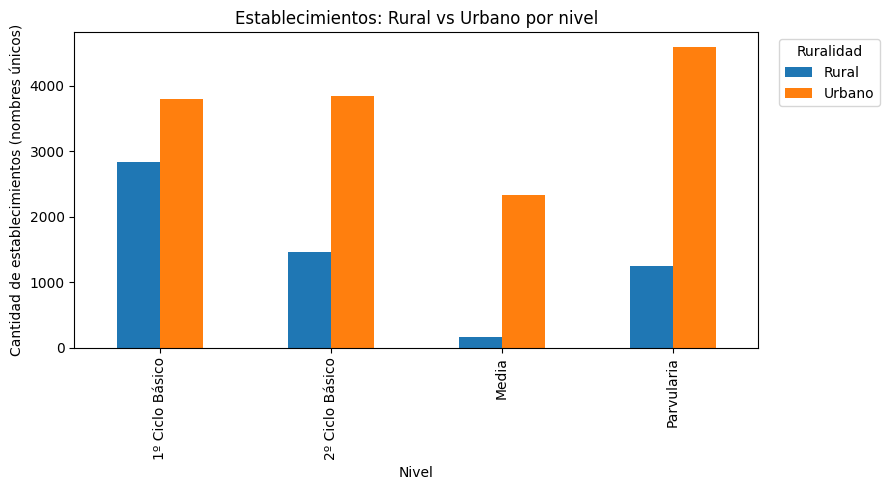


Conteo Rural/Urbano por nivel:
                 Rural  Urbano
nivel                         
1º Ciclo Básico   2834    3802
2º Ciclo Básico   1466    3846
Media              169    2330
Parvularia        1241    4591


In [62]:
# columnas para graficar
col_rural = "DS_RURALIDAD"
col_ivm   = "IVM Establecimiento"
col_nom   = "DS_NOM_ESTABLE"
col_com   = "DS_COMUNA_ESTABLE"

# cantidad de establecimientos rurales vs urbanos según nivel
# quitar filas sin info de ruralidad, agrupar por nivel y ruralidad y contar establecimientos unicos por nombre
tabla_ruralidad = (
    df_todos
    .dropna(subset=[col_rural])
    .groupby(["nivel", col_rural])[col_nom]
    .nunique()
    .unstack(fill_value=0)
)

# Grafico
fig, ax = plt.subplots(figsize=(9, 5))
tabla_ruralidad.plot(kind="bar", ax=ax)
ax.set_title("Establecimientos: Rural vs Urbano por nivel")
ax.set_xlabel("Nivel")
ax.set_ylabel("Cantidad de establecimientos (nombres únicos)")
ax.legend(title="Ruralidad", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

# conteo de rural y urbano por nivel (al final)
cols = tabla_ruralidad.columns.tolist()
rural_cols = [c for c in cols if "rural" in str(c).lower()]
urb_cols   = [c for c in cols if "urb" in str(c).lower()]

conteo = pd.DataFrame(index=tabla_ruralidad.index)
conteo["Rural"]  = tabla_ruralidad[rural_cols].sum(axis=1) if rural_cols else 0
conteo["Urbano"] = tabla_ruralidad[urb_cols].sum(axis=1) if urb_cols else 0

print("\nConteo Rural/Urbano por nivel:")
print(conteo)



* **Las cantidades oscilan principalmente hacia establecimientos urbanos donde por cada nivel hay como minimo 2000, siendo donde mas diferencia hay entre urbanos y rurales los niveles de media y parvulario dado que en parvularia hay apenas mil y en media menos de 500**

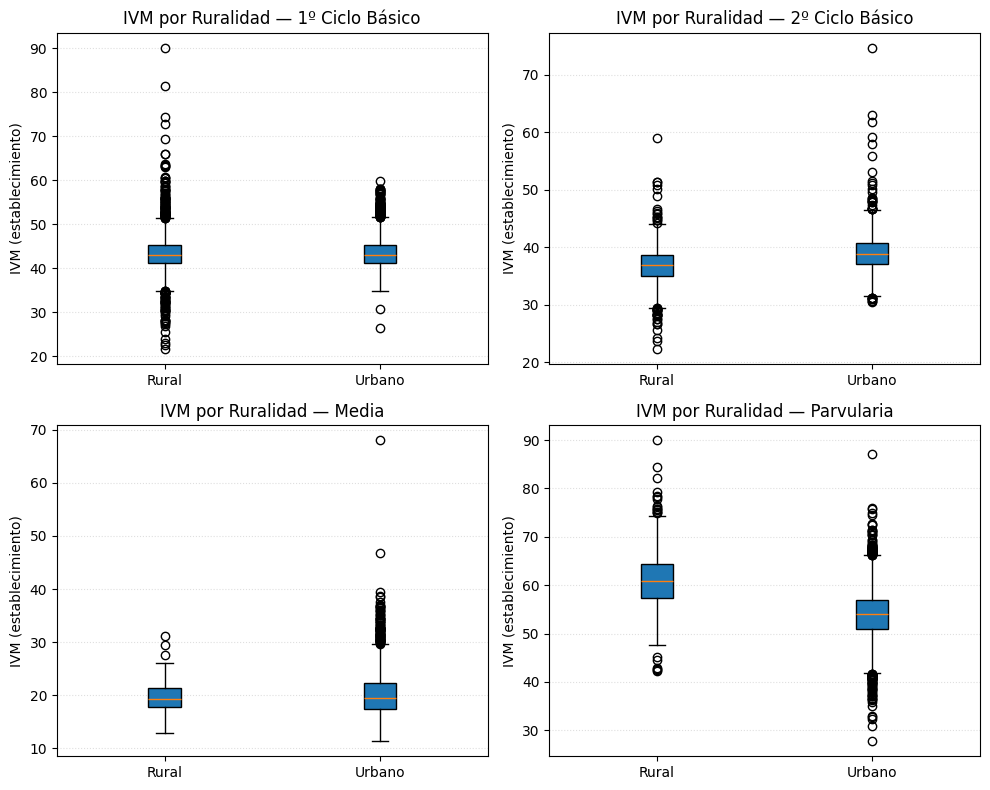

In [63]:
# Nos quedamos con filas que tengan IVM y ruralidad
df_ivm = df_todos.dropna(subset=[col_ivm, col_rural]).copy()

# subplots por nivel 
niveles = df_ivm["nivel"].unique().tolist()
n = len(niveles)
cols = 2
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(10, 4 * rows), squeeze=False)

for i, nivel in enumerate(sorted(niveles)):
    ax = axes[i // cols][i % cols]
    grupo = df_ivm[df_ivm["nivel"] == nivel]
    categorias = sorted(grupo[col_rural].unique())
    datos = [grupo[grupo[col_rural] == c][col_ivm].values for c in categorias]
    # dibujar caja por categoría 
    ax.boxplot(datos, patch_artist=True)
    ax.set_xticklabels(categorias)
    ax.set_title(f"IVM por Ruralidad — {nivel}")
    ax.set_ylabel("IVM (establecimiento)")
    ax.grid(axis="y", linestyle=":", alpha=0.4)


plt.tight_layout()
plt.show()

#### De este grafico se puede apreciar diferentes cosas
* **A nivel de ciclo basico 1 y 2 se aprecia que donde mas dispersion se encuentra es a establecimientos de caracter rural mientras que en el urbano se suele encontrar distribuido en un mismo percentil la distribucion, esta caracteristica del urbano tambien aplica al nivel de media pero aqui no es posible realizar mucho analisis por la escaza cantidad de establecimientos de este nivel que hay a nivel rural, ya como ultimo caso esta el nivel parvulario donde la mayor distribucion aparece en el urbano en vez de en el rural lo cual destacaria que hay demasiados colegios parvularios donde se ven diferentes niveles de vulnerabilidad, si bien tambien puede corresponder a la mayor cantidad de establecimientos de este nivel es destacable como se distribuye la vulnerabilidad en este tipo de establecimientos**

### 4.2 Tipo de establecimiento (0.7 pts)

* ¿Cómo es la distribución del IVM promedio de los establecimientos según tipo de dependencia y nivel de enseñanza? 

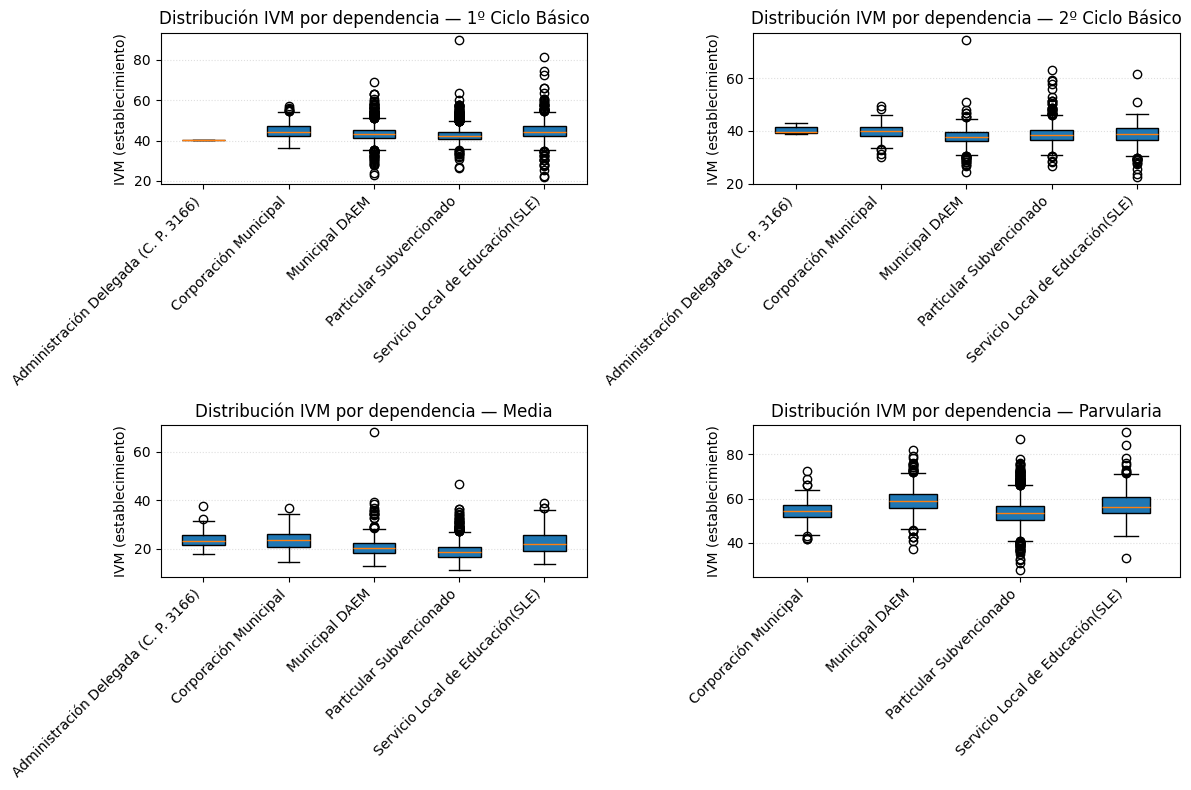

In [64]:
col_dep = "DS_TIPO_DEPENDENCIA"
col_ivm = "IVM Establecimiento"
col_nom = "DS_NOM_ESTABLE"

# IVM promedio por dependencia y nivel
tabla_ivm_promedio = (
    df_todos
    .dropna(subset=[col_ivm, col_dep])
    .groupby([col_dep, "nivel"])[col_ivm]
    .mean()
    .round(3)
)

# boxplots por nivel (IVM por tipo de dependencia)
df_ivm = df_todos.dropna(subset=[col_ivm, col_dep]).copy()
niveles = sorted(df_ivm["nivel"].unique().tolist())
cols = 2
rows = (len(niveles) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)
for i, nivel in enumerate(niveles):
    ax = axes[i // cols][i % cols]
    grupo = df_ivm[df_ivm["nivel"] == nivel]
    categorias = sorted(grupo[col_dep].unique())
    datos = [grupo[grupo[col_dep] == c][col_ivm].values for c in categorias]
    ax.boxplot(datos, patch_artist=True)
    ax.set_xticklabels(categorias, rotation=45, ha="right")
    ax.set_title(f"Distribución IVM por dependencia — {nivel}")
    ax.set_ylabel("IVM (establecimiento)")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()

Respuesta y comentarios:
* **En los boxplots se ve que, salvo en Media, las dependencias municipales (DAEM/servicio local) tienden a tener medianas de IVM más altas y cajas más compactas, mientras que las particulares subvencionadas muestran medianas más bajas y mucha más dispersión (y varios outliers bajos). En Media el IVM está en general más bajo y homogéneo entre dependencias.**

### 4.3 Pregunta Bono: Dimensiones de vulnerabilidad (1 punto)

Para los niveles de enseñanza Parvularia y Básica Primer ciclo (1-4º), tenemos información sobre distintas dimensiones de que se utilizan para calcular el IVM, como condición socioeconómica familiar y comunal, salud, etc. 

* Para todo Chile, en promedio, ¿cuál es la dimensión con mayor puntaje de IVM para cada uno de estos dos niveles de enseñanza?

Parvularia, columnas: ['IVM Establecimiento', 'IVM Salud', 'IVM CSE Familiar', 'IVM Estimulación y Apoyo', 'IVM Familia', 'IVM CSE Comunal', 'IVM Derechos']
IVM Derechos                14.211
IVM CSE Comunal             18.128
IVM Salud                   27.910
IVM Estimulación y Apoyo    43.096
IVM CSE Familiar            43.194
IVM Establecimiento         55.460
IVM Familia                 70.667
-> Dimensión con mayor IVM promedio: IVM Familia = 70.667

1º Ciclo Básico, columnas: ['IVM Establecimiento', 'IVM Salud', 'IVM Discapacidad', 'IVM Educación', 'IVM Habitabilidad', 'IVM Familiar', 'IVM Participación', 'IVM CSE Familia', 'IVM CSE Comunal']
IVM Participación       5.327
IVM Discapacidad        5.925
IVM Educación          13.039
IVM Habitabilidad      20.741
IVM CSE Comunal        22.729
IVM Familiar           32.197
IVM Salud              43.102
IVM Establecimiento    43.522
IVM CSE Familia        54.391
-> Dimensión con mayor IVM promedio: IVM CSE Familia = 54.391



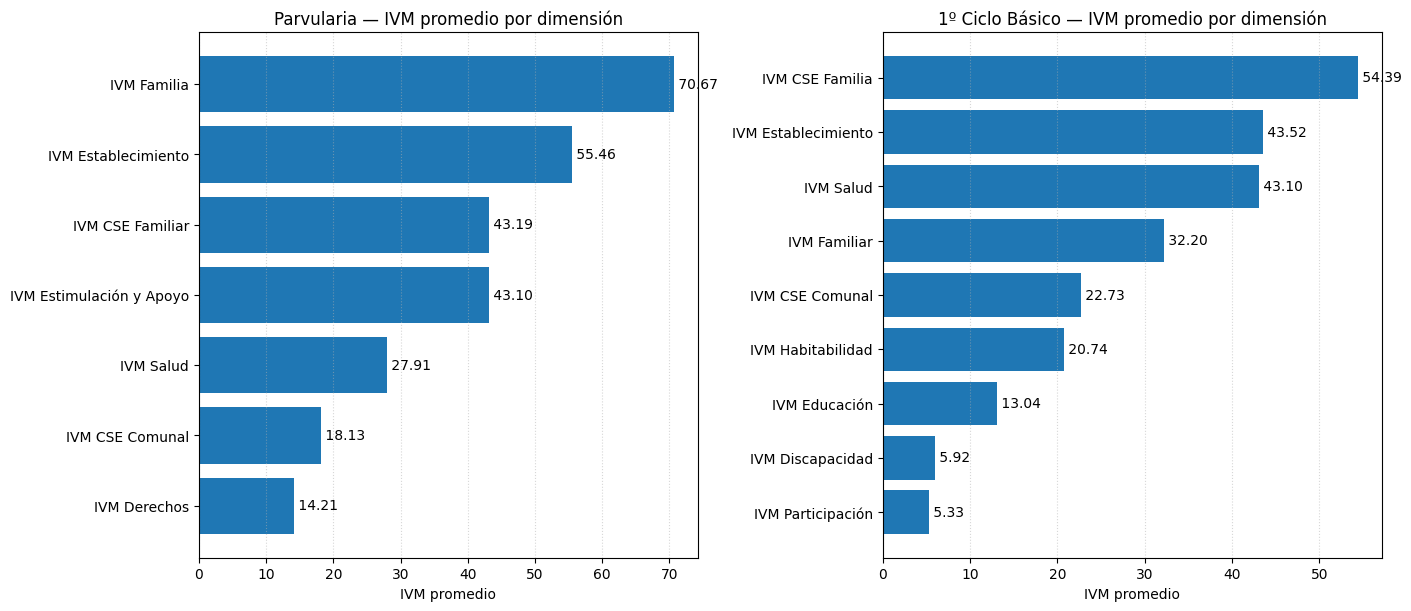

In [65]:
def columnas_dimensiones_ivm(df):
    excluir = ["bajo", "medio", "alto", "muy alto"]
    cols = []
    for c in df.columns:
        s = str(c).lower()
        if "ivm" in s and not any(e in s for e in excluir):
            cols.append(c)
    return cols

items = [("Parvularia", df_parvularia), ("1º Ciclo Básico", df_ciclo1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

for ax, (nombre, df) in zip(axes, items):
    cols = columnas_dimensiones_ivm(df)
    print(f"{nombre}, columnas: {cols}")
    medios = df[cols].apply(pd.to_numeric, errors="coerce").mean().round(3).sort_values(ascending=True)
    print(medios.to_string())
    print(f"-> Dimensión con mayor IVM promedio: {medios.idxmax()} = {medios.max()}\n")
    ax.barh(medios.index, medios.values)
    ax.set_title(f"{nombre} — IVM promedio por dimensión")
    ax.set_xlabel("IVM promedio")
    ax.grid(axis="x", linestyle=":", alpha=0.5)
    # anotaciones a la derecha de cada barra
    for val, idx in zip(medios.values, medios.index):
        ax.text(val, idx, f" {val:.2f}", va="center")

plt.show()

Respuesta y comentarios:
* **Para el caso del nivel parvulario el factor de vulnerabilidad mas preseente o con mayor puntuacion es la Familia, mientras que para el primer nivel basico el factor de vulnerabilidad con mayor puntuacion es el cse familia**

## 5. Agrupación de bases de datos (2 puntos)

El objetivo de esta sección será agrupar los establecimientos según la comuna en la que se encuentran para obtener un resumen general sobre la vulnerabilidad escolar en cada una de ellas. Al finalizar esta sección, tendremos un nuevo DataFrame `agg_comunal` que contenga, al menos, la siguiente información:

* Comuna (nombre y ID)
* Región (ID)
* Cantidad de establecimientos rurales de la comuna
* Cantidad de establecimientos urbanos de la comuna
* Cantidad total de establecimientos de la comuna
* Porcentaje de establecimientos rurales
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna
* Objeto geometry de GeoPandas correspondiente al polígono de la comuna respectiva

Armaremos este DataFrame paso a paso.

### 5.1 Cálculo de IVM promedio por comuna (0.8 pts)

Primero, para cada uno sus 4 DataFrames, calcule el promedio de la columna `IVM Establecimiento` según comuna. Almacene este valor en una nueva columna llamada `IVM Promedio {NIVEL DE ENSEÑANZA}` (por ejemplo, para enseñanza parvularia, cree la columna `IVM Promedio Parvularia`).

Junte los 4 resultados que obtuvo en un solo DataFrame `ivm_comunal` que contenga:
* Comuna (nombre y ID)
* Región (ID)
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna

Ponga siempre atención al tamaño de sus DataFrames: como estamos agrupando comunalmente, estos siempre debiesen tener una cantidad de filas igual a las comunas de Chile.

In [66]:
col_com_id  = "ID_COMUNA_ESTABLE"
col_com_nom = "DS_COMUNA_ESTABLE"
col_region  = "ID_REGION_ESTABLE"
col_ivm     = "IVM Establecimiento"

def promedio_ivm_por_comuna(df, nombre_nivel):
    df = df.copy()
    # asegurar columnas clave como strings
    if col_com_id in df.columns:
        df[col_com_id] = df[col_com_id].astype(str).str.strip()
    if col_com_nom in df.columns:
        df[col_com_nom] = df[col_com_nom].astype(str).str.strip()
    # garantizar columna de región (si falta, crearla con NA para homogeneidad)
    if col_region not in df.columns:
        df[col_region] = pd.NA
    else:
        df[col_region] = df[col_region].astype(str).str.strip()
    # convertir IVM a numérico y agrupar por comuna (ID, nombre, región)
    if col_ivm in df.columns:
        df[col_ivm] = pd.to_numeric(df[col_ivm], errors="coerce")
    agg = (
        df[[col_com_id, col_com_nom, col_region, col_ivm]]
        .groupby([col_com_id, col_com_nom, col_region], as_index=False)[col_ivm]
        .mean()
        .rename(columns={col_ivm: f"IVM Promedio {nombre_nivel}"})
    )
    # asegurar tipos
    agg[col_com_id] = agg[col_com_id].astype(str).str.strip()
    if col_com_nom in agg.columns:
        agg[col_com_nom] = agg[col_com_nom].astype(str).str.strip()
    agg[col_region] = agg[col_region].astype(str).str.strip().replace({"nan": pd.NA})
    return agg.round(3)

# calcular promedios
ivm_parv = promedio_ivm_por_comuna(df_parvularia, "Parvularia")
ivm_c1   = promedio_ivm_por_comuna(df_ciclo1,     "Primer Ciclo Básica")
ivm_c2   = promedio_ivm_por_comuna(df_ciclo2,     "Segundo Ciclo Básica")
ivm_med  = promedio_ivm_por_comuna(df_media,      "Media")

# unir todos en ivm_comunal (merge por ID, nombre y región)
ivm_comunal = (
    ivm_parv.merge(ivm_c1, on=[col_com_id, col_com_nom, col_region], how="outer")
            .merge(ivm_c2, on=[col_com_id, col_com_nom, col_region], how="outer")
            .merge(ivm_med, on=[col_com_id, col_com_nom, col_region], how="outer")
)

# limpieza final
ivm_comunal[col_com_id] = ivm_comunal[col_com_id].astype(str).str.strip()
if col_com_nom in ivm_comunal.columns:
    ivm_comunal = ivm_comunal.sort_values(col_com_nom).reset_index(drop=True)
else:
    ivm_comunal = ivm_comunal.reset_index(drop=True)

print("Filas en ivm_comunal:", len(ivm_comunal))
ivm_comunal.head()

Filas en ivm_comunal: 345


,ID_COMUNA_ESTABLE,DS_COMUNA_ESTABLE,ID_REGION_ESTABLE,IVM Promedio Parvularia,IVM Promedio Primer Ciclo Básica,IVM Promedio Segundo Ciclo Básica,IVM Promedio Media
0,5602,Algarrobo,5,54.410,42.617,37.361,17.935
1,13502,Alhué,13,57.602,42.181,37.536,20.392
2,8314,Alto Biobío,8,74.731,42.930,34.048,19.715
3,1107,Alto Hospicio,1,55.420,46.600,41.289,24.250
4,3302,Alto del Carmen,3,63.914,41.493,35.489,22.397


### 5.2 Establecimientos por comuna y ruralidad (0.8 pts)

Ahora contaremos la cantidad de establecimientos por comuna según ruralidad. Como buscamos la cantidad total de establecimientos, consideramos establecimientos de todos los niveles educacionales vistos. Para esto, combine los 4 DataFrames que cargó y genere un nuevo DataFrame `estab_comunal` que contenga:

* Comuna (ID)
* Cantidad de establecimientos rurales
* Cantidad de establecimientos urbanos
* Cantidad total de establecimientos
* Porcentaje de establecimientos rurales (Establecimientos rurales / Total establecimientos * 100)

Tenga en cuenta de que pueden aparecer establecimientos duplicados al combinar estos 4 DataFrames (por ejemplo, establecimientos que imparten múltiples niveles de enseñanza, desde 1º básico hasta 4º medio). Preocúpese de manejar estos casos antes de agrupar sus datos según ruralidad.

In [67]:
col_com_id = "ID_COMUNA_ESTABLE"
col_com_nom = "DS_COMUNA_ESTABLE"
col_rural = "DS_RURALIDAD"
col_rbd = "ID_RBD"
col_nom = "DS_NOM_ESTABLE"

df_all = pd.concat([df_parvularia, df_ciclo1, df_ciclo2, df_media], ignore_index=True)

df_all[col_com_id] = df_all[col_com_id].astype(str).str.strip()
df_all[col_com_nom] = df_all[col_com_nom].astype(str).str.strip()

if col_rbd in df_all.columns:
    df_all[col_rbd] = df_all[col_rbd].astype(str).str.strip()
    df_unicos = (
        df_all
        .groupby(col_rbd, as_index=False)
        .agg({col_com_id: "first", col_com_nom: "first", col_rural: "first"})
    )

conteos = (
    df_unicos
    .groupby([col_com_id, col_com_nom, col_rural])
    .size()
    .reset_index(name="conteo")
)

pivot = conteos.pivot_table(index=[col_com_id, col_com_nom], columns=col_rural, values="conteo", aggfunc="sum", fill_value=0)
pivot = pivot.rename_axis(columns=None).reset_index()
if "Rural" not in pivot.columns:
    pivot["Rural"] = 0
if "Urbano" not in pivot.columns:
    pivot["Urbano"] = 0

pivot["Total_establecimientos"] = pivot["Rural"] + pivot["Urbano"]
pivot["Pct_establecimientos_rurales"] = (pivot["Rural"] / pivot["Total_establecimientos"] * 100).round(2)

estab_comunal = pivot[[col_com_id, col_com_nom, "Rural", "Urbano", "Total_establecimientos", "Pct_establecimientos_rurales"]].sort_values(col_com_nom).reset_index(drop=True)
estab_comunal[col_com_id] = estab_comunal[col_com_id].astype(str).str.strip()

print("Filas en estab_comunal:", estab_comunal.shape[0])
estab_comunal.head()

Filas en estab_comunal: 345


,ID_COMUNA_ESTABLE,DS_COMUNA_ESTABLE,Rural,Urbano,Total_establecimientos,Pct_establecimientos_rurales
0,5602,Algarrobo,3,5,8,37.50
1,13502,Alhué,4,1,5,80.00
2,8314,Alto Biobío,9,0,9,100.00
3,1107,Alto Hospicio,3,41,44,6.82
4,3302,Alto del Carmen,15,0,15,100.00


### 5.3 Unión de bases de datos y polígonos (0.4 pts)

Finalmente, vamos a generar el DataFrame `agg_comunal` con la información de los dos previos DataFrames creados.
Combine la información de las dos secciones anteriores para crear su base de datos unificada. Por último, agregue la columna `geometry` con la información geográfica de cada comuna.

In [68]:
col_com_id  = "ID_COMUNA_ESTABLE"
col_com_nom = "DS_COMUNA_ESTABLE"
col_region  = "ID_REGION_ESTABLE"

ivm_comunal[col_com_id]  = ivm_comunal[col_com_id].astype(str).str.strip()
ivm_comunal[col_com_nom] = ivm_comunal[col_com_nom].astype(str).str.strip()
estab_comunal[col_com_id]  = estab_comunal[col_com_id].astype(str).str.strip()
estab_comunal[col_com_nom] = estab_comunal[col_com_nom].astype(str).str.strip()

merge_keys = [col_com_id, col_com_nom]

agg = ivm_comunal.merge(estab_comunal, on=merge_keys, how="outer", suffixes=("", "_estab"))

for c in agg.columns:
    if c.endswith("_estab"):
        base = c.replace("_estab", "")
        if base in agg.columns:
            agg[base] = agg[base].combine_first(agg[c])
        else:
            agg = agg.rename(columns={c: base})
agg = agg.loc[:, ~agg.columns.duplicated()]

gdf_geom = gdf_comunas[[col_com_id, "geometry"]].drop_duplicates(subset=[col_com_id]).copy()
gdf_geom[col_com_id] = gdf_geom[col_com_id].astype(str).str.strip()

agg = agg.merge(gdf_geom, on=col_com_id, how="left")

agg = gpd.GeoDataFrame(agg, geometry="geometry", crs=gdf_comunas.crs)
agg = agg.drop_duplicates(subset=[col_com_id, col_com_nom]).reset_index(drop=True)

front = [col_region, col_com_id, col_com_nom]
front = [c for c in front if c in agg.columns]
rest  = [c for c in agg.columns if c not in front + ["geometry"]]
agg   = agg[front + rest + ["geometry"]]

agg_comunal = agg.copy()
print("Filas en agg_comunal:", len(agg_comunal))
agg_comunal.head()


Filas en agg_comunal: 345


,ID_REGION_ESTABLE,ID_COMUNA_ESTABLE,DS_COMUNA_ESTABLE,IVM Promedio Parvularia,IVM Promedio Primer Ciclo Básica,IVM Promedio Segundo Ciclo Básica,IVM Promedio Media,Rural,Urbano,Total_establecimientos,Pct_establecimientos_rurales,geometry
0,10,10101,Puerto Montt,55.011,44.204,39.694,20.562,42,90,132,31.82,"MULTIPOLYGON (((-73.04925 -41.6609, -73.05004 ..."
1,10,10102,Calbuco,63.074,40.890,36.793,19.259,35,10,45,77.78,"MULTIPOLYGON (((-72.88003 -41.91123, -72.88037..."
2,10,10103,Cochamó,69.520,43.341,34.931,19.520,10,0,10,100.00,"MULTIPOLYGON (((-72.58418 -41.715, -72.58414 -..."
3,10,10104,Fresia,58.406,43.962,36.973,17.952,16,4,20,80.00,"MULTIPOLYGON (((-73.89985 -41.17444, -73.89983..."
4,10,10105,Frutillar,58.500,44.480,35.602,18.862,13,10,23,56.52,"POLYGON ((-73.10172 -40.97955, -73.10158 -40.9..."


## 6. Análisis de vulnerabilidad por comuna (1.5 puntos)

### 6.1 Mapa de calor (0.8 pts)

Genere mapas de calor de las comunas de Chile según el IVM promedio de los establecimientos educacionales. Realice esto para cada etapa de enseñanza (Parvularia, Básica 1, Básica 2 y Media). Analice y comente sus resultados:
* ¿Cómo se diferencia la vulnerabilidad en distintos sectores del país según nivel de enseñanza?

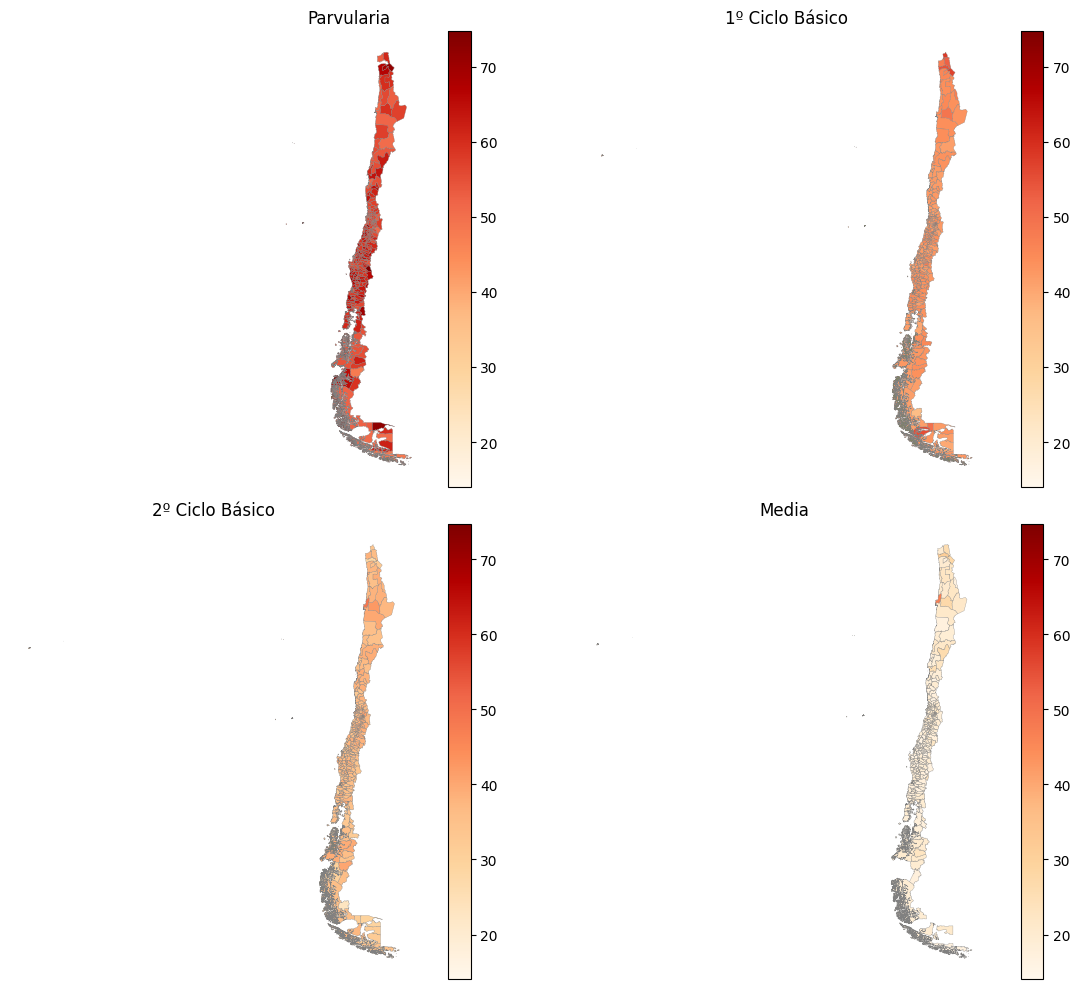

In [69]:
niveles = {
    "Parvularia": "IVM Promedio Parvularia",
    "1º Ciclo Básico": "IVM Promedio Primer Ciclo Básica",
    "2º Ciclo Básico": "IVM Promedio Segundo Ciclo Básica",
    "Media": "IVM Promedio Media"
}

cols = [c for c in niveles.values() if c in agg_comunal.columns]
vmin = agg_comunal[cols].min().min()
vmax = agg_comunal[cols].max().max()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (nivel, col) in zip(axes, niveles.items()):
    if col not in agg_comunal.columns:
        ax.axis("off")
        continue
    agg_comunal.plot(
        column=col,
        ax=ax,
        cmap="OrRd",
        legend=True,
        vmin=vmin,
        vmax=vmax,
        edgecolor="grey",
        linewidth=0.2
    )
    ax.set_title(f"{nivel}")
    ax.axis("off")

plt.tight_layout()
plt.show()


Comentarios y análisis:
* **Por lo general suelen estar bastante estables llendo de mas vulnerabilidad a menos dependiendo del nivel de enseñanza habiendo mas vulnerabilidad para el nivel parvulario a nivel pais mientras que conforme se va subiendo el nivel de enseñanza va bajando drasticamente el nivel de vulnerabilidad**

### 6.2 Relación entre ruralidad comunal y vulnerabilidad (0.7 pts)

En la sección **5.2** definimos el **porcentaje de ruralidad** de cada comuna según la cantidad de establecimientos rurales en cada una. Analice y visualice los datos en `agg_comunal` para responder la siguiente pregunta:

* ¿Hay alguna correlación entre el IVM promedio y el porcentaje de ruralidad en las comunas de Chile?

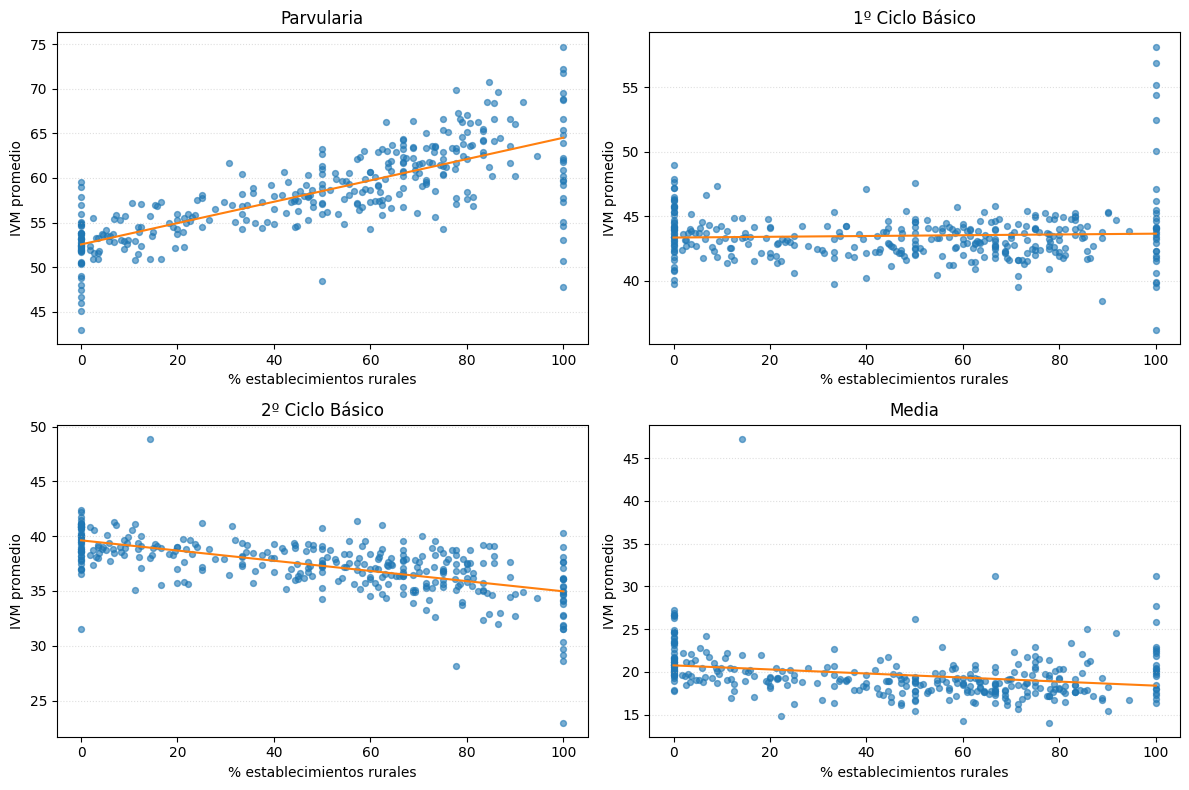

          Nivel  Pearson_r  Spearman_r   n
     Parvularia      0.764       0.788 338
1º Ciclo Básico      0.046      -0.024 345
2º Ciclo Básico     -0.607      -0.631 344
          Media     -0.266      -0.343 335


In [70]:
niveles = {
    "Parvularia": "IVM Promedio Parvularia",
    "1º Ciclo Básico": "IVM Promedio Primer Ciclo Básica",
    "2º Ciclo Básico": "IVM Promedio Segundo Ciclo Básica",
    "Media": "IVM Promedio Media"
}

pct_col = "Pct_establecimientos_rurales"

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
res = []

for ax, (nivel, col_ivm) in zip(axes, niveles.items()):
    if col_ivm not in agg_comunal.columns:
        ax.axis("off")
        continue

    df = agg_comunal[[pct_col, col_ivm]].dropna()
    x = df[pct_col].astype(float)
    y = df[col_ivm].astype(float)

    ax.scatter(x, y, s=18, alpha=0.6)
    coef = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, np.polyval(coef, xs), color="C1", lw=1.5)
    ax.set_xlabel("% establecimientos rurales")
    ax.set_ylabel("IVM promedio")
    ax.set_title(nivel)
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    r_p = x.corr(y)
    r_s = x.rank().corr(y.rank())
    res.append((nivel, round(r_p, 3), round(r_s, 3), len(df)))

for j in range(len(niveles), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

tabla_cor = pd.DataFrame(res, columns=["Nivel", "Pearson_r", "Spearman_r", "n"])
print(tabla_cor.to_string(index=False))


* **En general se nota que sí existe cierta relación entre el porcentaje de ruralidad comunal y el IVM promedio, aunque cambia según el nivel de enseñanza. en parvularia la correlación es más clara y positiva, o sea, mientras más rural es la comuna, mayor tiende a ser su nivel de vulnerabilidad. en el primer ciclo básico esa relación casi se pierde, los valores del IVM se mantienen bastante estables sin importar la ruralidad. ya en segundo ciclo la tendencia se revierte, mostrando una correlación negativa donde las comunas más rurales presentan, en promedio, menor vulnerabilidad que las urbanas, aunque igual con harta dispersión. en media pasa algo parecido, la correlación sigue siendo negativa pero más leve, y con datos más esparcidos, así que no se puede decir que la ruralidad tenga un efecto tan marcado sobre la vulnerabilidad en ese nivel.**

## 7 Pregunta Bono (2 punto)

* Proponga una pregunta de análisis que le interese responder con los datos de cualquiera de las bases de datos leídas o generadas durante esta Tarea.
Respóndala de la misma forma que las preguntas anteriores, generando una o varias visualizaciones y analizando sus resultados. Justifique 

**Recomendación**: Trate de proponer una pregunta que justifique el uso de agregación de datos y visualización. En otras palabras, que
no pueda ser respondida directamente sin el uso de gráficos (por ejemplo, *"¿cuál es el establecimiento con mayor IVM?"* puede ser respondida con una búsqueda rápida en el DataFrame).

**Pregunta propuesta:**

In [71]:
# respuesta